10 Feb 2026 LAB 3

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

In [2]:
import csv

retail = []

with open('OnlineRetail.csv', newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        retail.append(row)

print(retail[0]['UnitPrice'])


2.55


1. Find mean, std dev, min , max of unitprice field.

In [3]:
unit_pr = []
for entry in retail:
    unit_pr.append(float(entry['UnitPrice']))

print("mean: ", np.asarray(unit_pr).mean())
print("min: ", np.asarray(unit_pr).min())
print("max: ", np.asarray(unit_pr).max())
print("std: ", np.asarray(unit_pr).std())


mean:  4.611113626088513
min:  -11062.06
max:  38970.0
std:  96.75976378429183


2.  Draw histogram of unitprice field using matplotlib

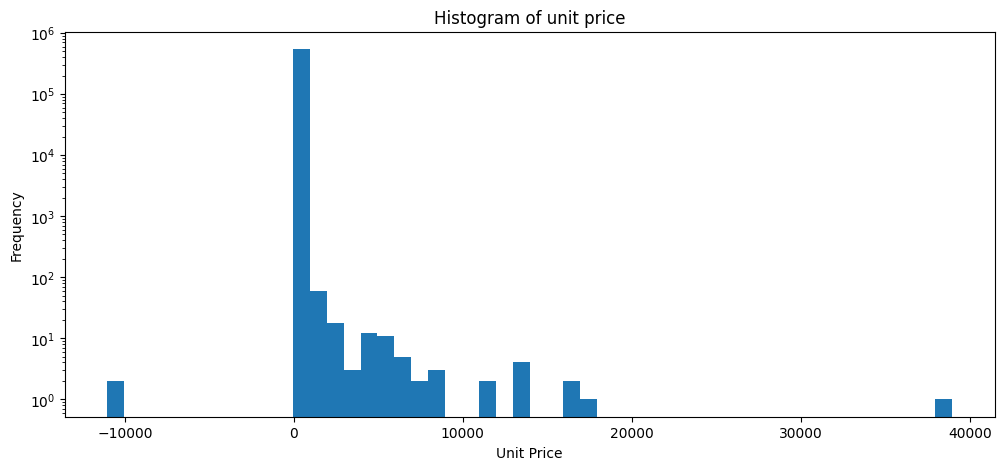

In [ ]:
plt.figure(figsize=(12, 5))
plt.hist(unit_pr, bins=50)
plt.yscale('log')
plt.ylabel("Frequency")
plt.xlabel("Unit Price")
plt.title("Histogram of unit price")
plt.show()

3. Find mean of unitprice group by country and plot them

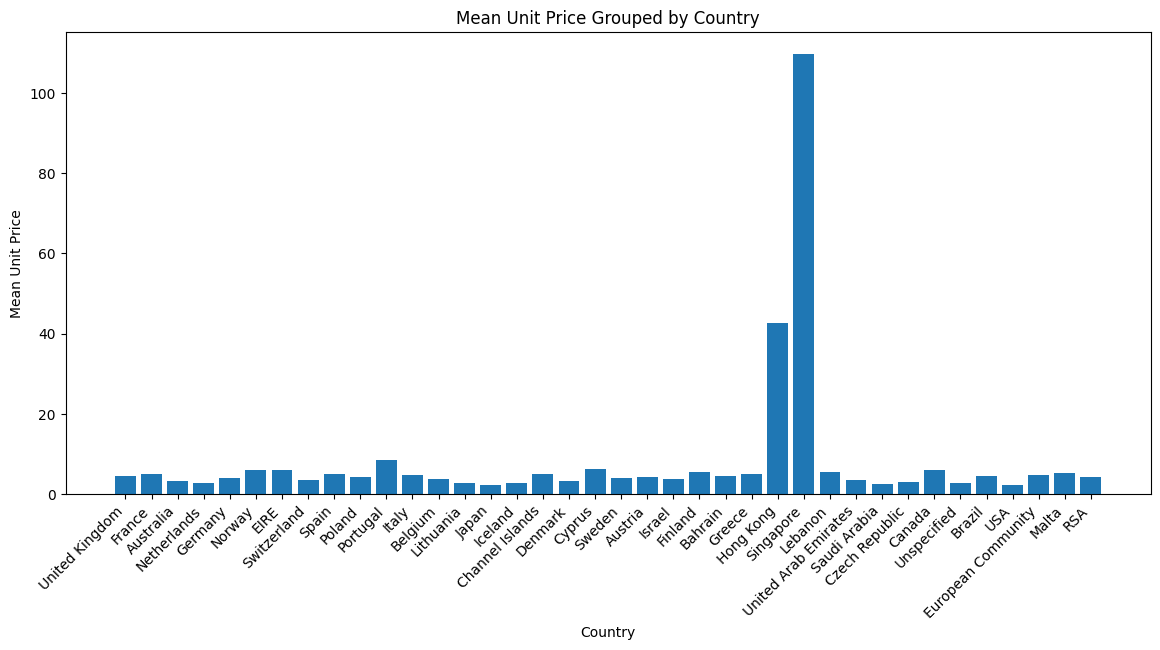

In [ ]:
price_sum = {}
country_count = {}

for item in retail:
    country = item['Country']
    price = float(item['UnitPrice'])

    if country in price_sum:
        price_sum[country] += price
        country_count[country] += 1
    else:
        price_sum[country] = price
        country_count[country] = 1

mean_price = {}
for country in price_sum:
    mean_price[country] = price_sum[country] / country_count[country]

plt.figure(figsize=(14, 6))
plt.bar(mean_price.keys(), mean_price.values())
plt.xlabel("Country")
plt.ylabel("Mean Unit Price")
plt.title("Mean Unit Price Grouped by Country")
plt.xticks(rotation=45, ha='right')
plt.show()


4. Find min and max of unit price group by customerID

In [36]:
customer = {}

for item in retail:
    id = item['CustomerID']
    price = float(item['UnitPrice'])

    if id in customer:
        customer[id]['max'] = np.max([customer[id]['max'], price])
        customer[id]['min'] = np.min([customer[id]['min'], price])
        
    else:
        customer[id] = {
            'min': price,
            'max': price
        }


In [39]:
for id in customer:
    print(f"CustomerID: {id} | Min UnitPrice: {customer[id]['min']} | Max UnitPrice: {customer[id]['max']}")

CustomerID: 17850 | Min UnitPrice: 1.06 | Max UnitPrice: 35.75
CustomerID: 13047 | Min UnitPrice: 0.42 | Max UnitPrice: 14.95
CustomerID: 12583 | Min UnitPrice: 0.06 | Max UnitPrice: 18.0
CustomerID: 13748 | Min UnitPrice: 0.39 | Max UnitPrice: 14.95
CustomerID: 15100 | Min UnitPrice: 10.95 | Max UnitPrice: 10.95
CustomerID: 15291 | Min UnitPrice: 0.29 | Max UnitPrice: 45.0
CustomerID: 14688 | Min UnitPrice: 0.19 | Max UnitPrice: 25.0
CustomerID: 17809 | Min UnitPrice: 0.21 | Max UnitPrice: 717.23
CustomerID: 15311 | Min UnitPrice: 0.12 | Max UnitPrice: 14.95
CustomerID: 14527 | Min UnitPrice: 0.19 | Max UnitPrice: 80.0
CustomerID: 16098 | Min UnitPrice: 0.29 | Max UnitPrice: 21.95
CustomerID: 18074 | Min UnitPrice: 0.65 | Max UnitPrice: 12.75
CustomerID: 17420 | Min UnitPrice: 1.25 | Max UnitPrice: 19.95
CustomerID: 16029 | Min UnitPrice: 0.2 | Max UnitPrice: 8142.75
CustomerID: 16250 | Min UnitPrice: 0.42 | Max UnitPrice: 7.95
CustomerID: 12431 | Min UnitPrice: 0.0 | Max UnitPrice: 1

5. Find cumulative sales monthly and yearly and plot them using both Matplotlib and Sea Borne.

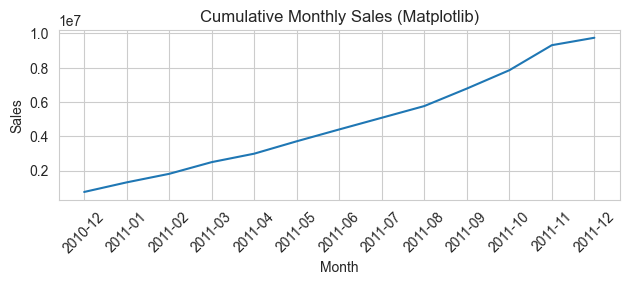

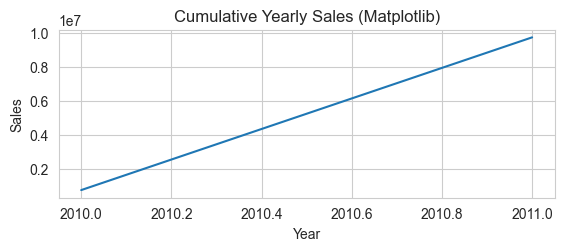

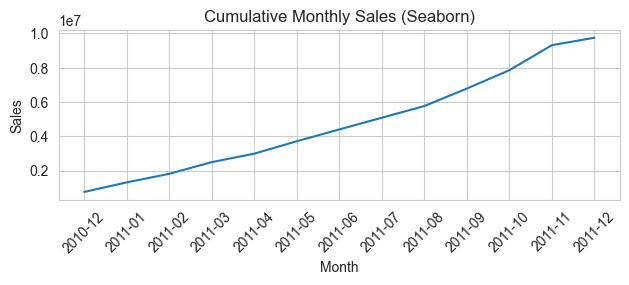

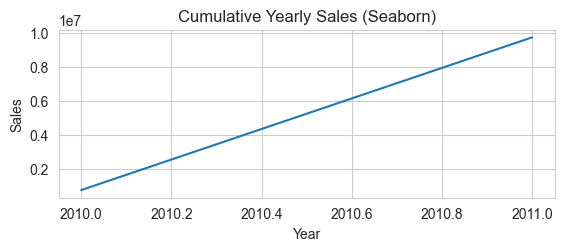

In [52]:
from datetime import datetime

monthly_sales = {}
yearly_sales = {}

for item in retail:
    date = datetime.strptime(item['InvoiceDate'], "%m/%d/%Y %H:%M")
    sale = float(item['Quantity']) * float(item['UnitPrice'])

    month_key = date.strftime("%Y-%m")
    year_key = date.year

    monthly_sales[month_key] = monthly_sales.get(month_key, 0) + sale
    yearly_sales[year_key] = yearly_sales.get(year_key, 0) + sale

months = sorted(monthly_sales)
years = sorted(yearly_sales)

cum_monthly = []
cum_yearly = []

total = 0
for m in months:
    total += monthly_sales[m]
    cum_monthly.append(total)

total = 0
for y in years:
    total += yearly_sales[y]
    cum_yearly.append(total)

# Matplotlib 
plt.subplot(2,1,1)
plt.plot(months, cum_monthly)
plt.xticks(rotation=45)
plt.title("Cumulative Monthly Sales (Matplotlib)")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

plt.subplot(2,1,2)
plt.plot(years, cum_yearly)
plt.title("Cumulative Yearly Sales (Matplotlib)")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

# Seaborn 
sns.set_style("whitegrid")

plt.subplot(2,1,1)
sns.lineplot(x=months, y=cum_monthly)
plt.xticks(rotation=45)
plt.title("Cumulative Monthly Sales (Seaborn)")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

plt.subplot(2,1,1)
sns.lineplot(x=years, y=cum_yearly)
plt.title("Cumulative Yearly Sales (Seaborn)")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()


6. Generate a Box plot for each attribute

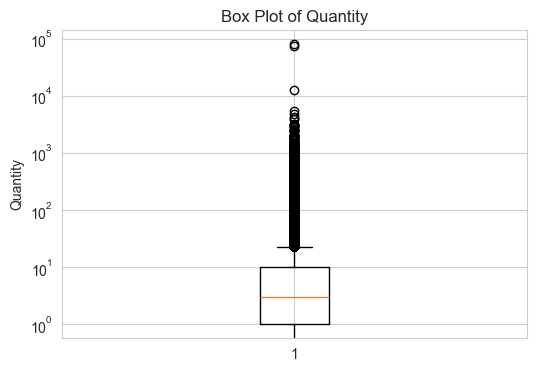

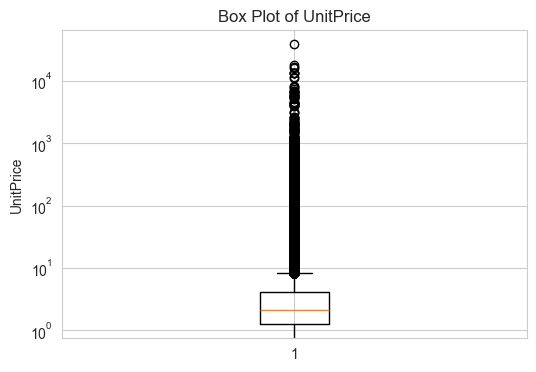

In [78]:
numeric_fields = ['Quantity', 'UnitPrice']

for field in numeric_fields:
    values = []

    for item in retail:
        if not values.append(float(item[field])):
            continue

        else:
           values.append(float(item[field])) 

    plt.figure(figsize=(6, 4))
    plt.boxplot(values, vert=True)
    plt.title(f"Box Plot of {field}")
    plt.ylabel(field)
    plt.yscale("log")
    plt.show()


7. Analyze each attribute using the factor plot analysis using Seaborne library

In [ ]:

countries = [item['Country'] for item in retail]
quantities = [float(item['Quantity']) for item in retail]
unit_prices = [float(item['UnitPrice']) for item in retail]

freq_dict = {}
cust_freq = []

for item in retail:
    id = item['CustomerID']
    if id in freq_dict:
        freq_dict[id] += 1
    else:
        freq_dict[id] = 1

for item in retail:
    cust_freq.append(freq_dict[item['CustomerID']])


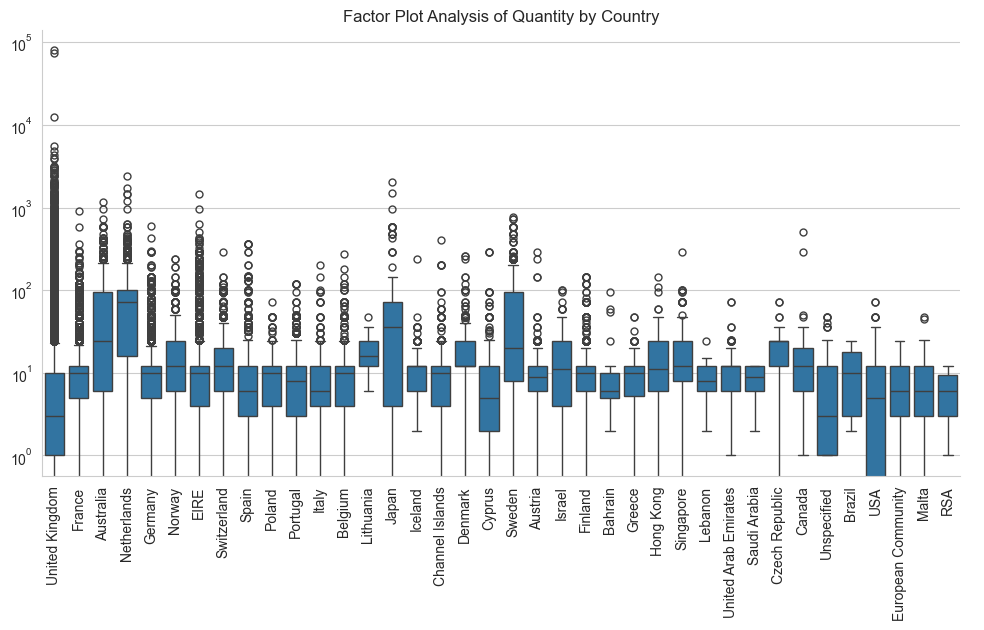

In [80]:
# ---------- Factor plot for Quantity ----------
sns.catplot(
    x=countries,
    y=quantities,
    kind="box",
    height=5,
    aspect=2
)
plt.xticks(rotation=90)
plt.yscale("log")
plt.title("Factor Plot Analysis of Quantity by Country")
plt.show()

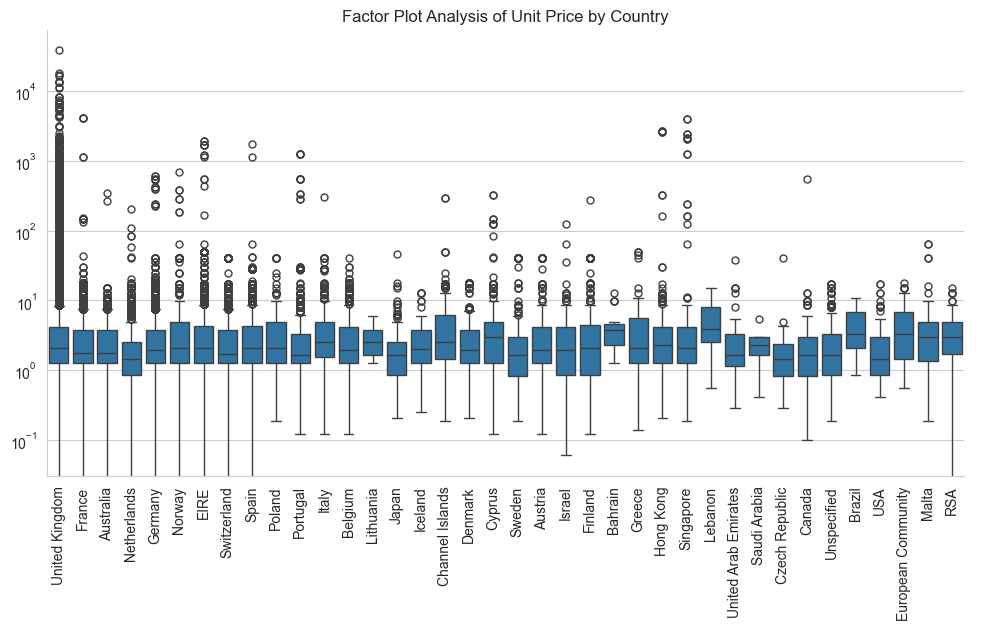

In [79]:
# ---------- Factor plot for UnitPrice ----------
sns.catplot(
    x=countries,
    y=unit_prices,
    kind="box",
    height=5,
    aspect=2
)
plt.xticks(rotation=90)
plt.yscale("log")
plt.title("Factor Plot Analysis of Unit Price by Country")
plt.show()

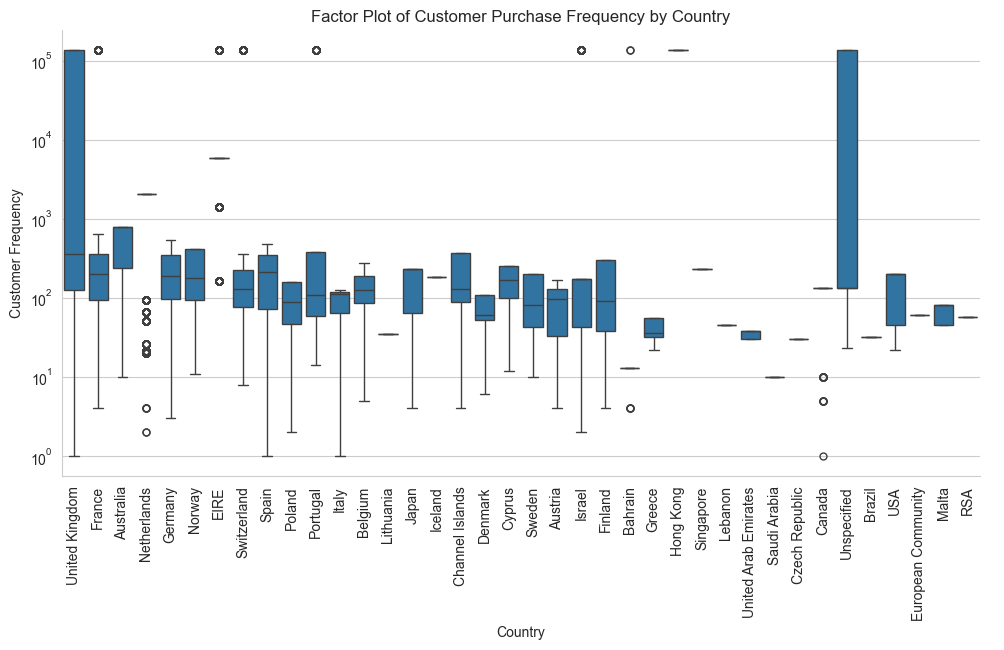

In [81]:
# Factor Plot of Customer Purchase Frequency

sns.catplot(
    x=countries,
    y=cust_freq,
    kind="box",
    height=5,
    aspect=2
)

plt.xticks(rotation=90)
plt.yscale("log")
plt.title("Factor Plot of Customer Purchase Frequency by Country")
plt.xlabel("Country")
plt.ylabel("Customer Frequency")
plt.show()